In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "gpu"

import jax
import jax.numpy as jnp
import flax.linen as nn
import netket as nk
import optax
import numpy as np
import matplotlib.pyplot as plt
import json
import flax.serialization as serialization
from tqdm import tqdm

print(jax.devices())

from src_renyi import (
    ARNN_Z2, RBM_Z2,
    FreeRenyiEnergyObservable,
    free_energy_minimize_SR_SGD,
    free_energy_minimize_scipy,
    renyi_entropy_maximize_SR_SGD,
    renyi2_entropy_and_grad_sampled,
    renyi2_entropy_and_grad_sampled2,
    renyi2_entropy_and_grad_lambda_integral,
    renyi2_entropy_and_grad_cv
)

[CudaDevice(id=0)]


In [2]:
# Hilbert space
from netket.hilbert import Spin
N = 4
N_ancilla = 4
partition = list(range(N))

# System: N 1/2
# Ancilla: N_ancilla  1/2
# Total space = spin ⊗ ancilla
hi_system = nk.hilbert.Spin(s=1/2, N=N)
hi_ancilla = nk.hilbert.Spin(s=1/2, N=N_ancilla)
hi_extended = nk.hilbert.Spin(s=1/2, N=N+N_ancilla)

partition = list(range(N)) 

$\mathcal{H_0}=Γ \sum_{i}\sigma_i^{(x)}+V\sum_{i}\sigma_i^{(z)}\sigma_{i+1}^{z} \qquad \mathcal{H_R}=\mathbb{I}_R$

$\mathcal{H}=\mathcal{H_0}\otimes\mathbb{I}_R$

In [3]:
# Pauli matrices import, Hamiltonian  H = H_0 ⊗ I_R
from netket.operator.spin import sigmax, sigmaz
Gamma = -1.5  
V = -1
H_system=0
H_extended = 0

for i in range(N):
    H_system += Gamma * sigmax(hi_system, i)
    H_system += V * sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N)

for i in range(N):
    H_extended += Gamma * sigmax(hi_extended, i)
    H_extended += V * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)

$F_R=\langle H \rangle -TS_2$

Necesitamos una función que calcule $S_2$ y su gradiente. Utilizaremos:

$S_2=-\log(Tr(\rho_A^2))=-\log\left\langle\frac{\psi(r,\eta')\psi(r',\eta)}{\psi(r,\eta)\psi(r',\eta')}\right\rangle$

Quantum Neural Network training at a given temperature

Step    0 | F=-3.612160 | t=7.020s
Step   20 | F=-7.345171 | t=0.040s
Step   40 | F=-7.441034 | t=0.044s
Step   60 | F=-7.483166 | t=0.041s
Step   80 | F=-7.457580 | t=0.040s
Step  100 | F=-7.463867 | t=0.046s
Step  120 | F=-7.452001 | t=0.041s
Step  140 | F=-7.441852 | t=0.040s
Step  160 | F=-7.469035 | t=0.042s
Step  180 | F=-7.459599 | t=0.051s
Step  200 | F=-7.453610 | t=0.047s
Step  220 | F=-7.480952 | t=0.045s
Step  240 | F=-7.426621 | t=0.049s
Step  260 | F=-7.445382 | t=0.045s
Step  280 | F=-7.509865 | t=0.044s


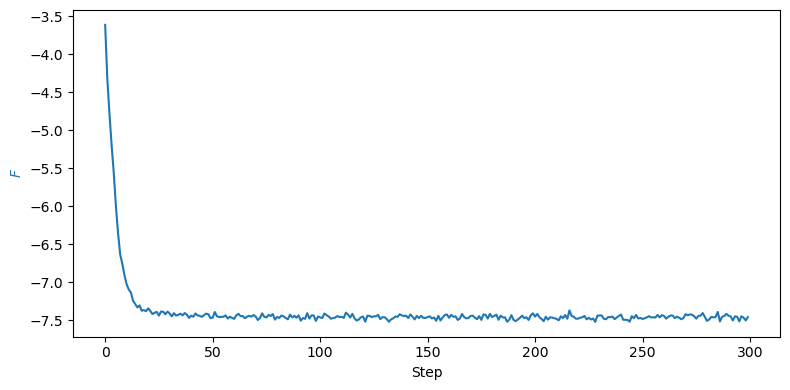

Best solution: S₂=0.981336, E=-5.695700, F=-7.462106


In [4]:
sampler = nk.sampler.ARDirectSampler(hi_extended)

arnn = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
model = ARNN_Z2(worker=arnn, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=40960*1)
T = 1.8

n_steps = 300
lr = optax.linear_schedule(0.05, 0.001, n_steps)
diag_shift = optax.linear_schedule(1e-1, 1e-4, n_steps)
_,f_best,E_best,S_best = free_energy_minimize_SR_SGD(vstate, T, partition, H_extended, n_steps, learning_rate=lr,
                                                      diag_shift=diag_shift, freq=20, timing=True, n_samples_sr=4096)
print(f"Best solution: S₂={S_best:.6f}, E={E_best:.6f}, F={f_best:.6f}")

Training at different temperatures

In [12]:
print(np.linspace(0, 5, 21))

[0.   0.25 0.5  0.75 1.   1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   3.25
 3.5  3.75 4.   4.25 4.5  4.75 5.  ]


Temperaturas:   0%|          | 0/11 [00:00<?, ?it/s]


=== Temperatura T = 0.000 ===
Step    0 | F=-6.037476
Step   50 | F=-6.759666
Step  100 | F=-6.760149
Step  150 | F=-6.760268
Step  200 | F=-6.759930
Step  250 | F=-6.759993


Temperaturas:   9%|▉         | 1/11 [00:17<02:55, 17.51s/it]

  Mejor resultado: E=-6.7597, S₂=0.0000, F=-6.7597

=== Temperatura T = 0.500 ===
Step    0 | F=-6.759676
Step   50 | F=-6.760061
Step  100 | F=-6.760281
Step  150 | F=-6.760161
Step  200 | F=-6.759358
Step  250 | F=-6.759182


Temperaturas:  18%|█▊        | 2/11 [00:26<01:51, 12.44s/it]

...

  Mejor resultado: E=-1.9441, S₂=2.5343, F=-12.0811

=== Temperatura T = 4.500 ===
Step    0 | F=-13.128276
Step   50 | F=-13.149859
Step  100 | F=-13.344311
Step  150 | F=-12.802941
Step  200 | F=-13.168686
Step  250 | F=-13.308939


Temperaturas:  91%|█████████ | 10/11 [01:45<00:10, 10.22s/it]

  Mejor resultado: E=-1.7379, S₂=2.5670, F=-13.2892

=== Temperatura T = 5.000 ===
Step    0 | F=-14.628351
Step   50 | F=-14.171195
Step  100 | F=-14.581666
Step  150 | F=-14.460863
Step  200 | F=-14.875287
Step  250 | F=-14.620379


Temperaturas: 100%|██████████| 11/11 [01:56<00:00, 10.55s/it]

  Mejor resultado: E=-1.3905, S₂=2.6359, F=-14.5702


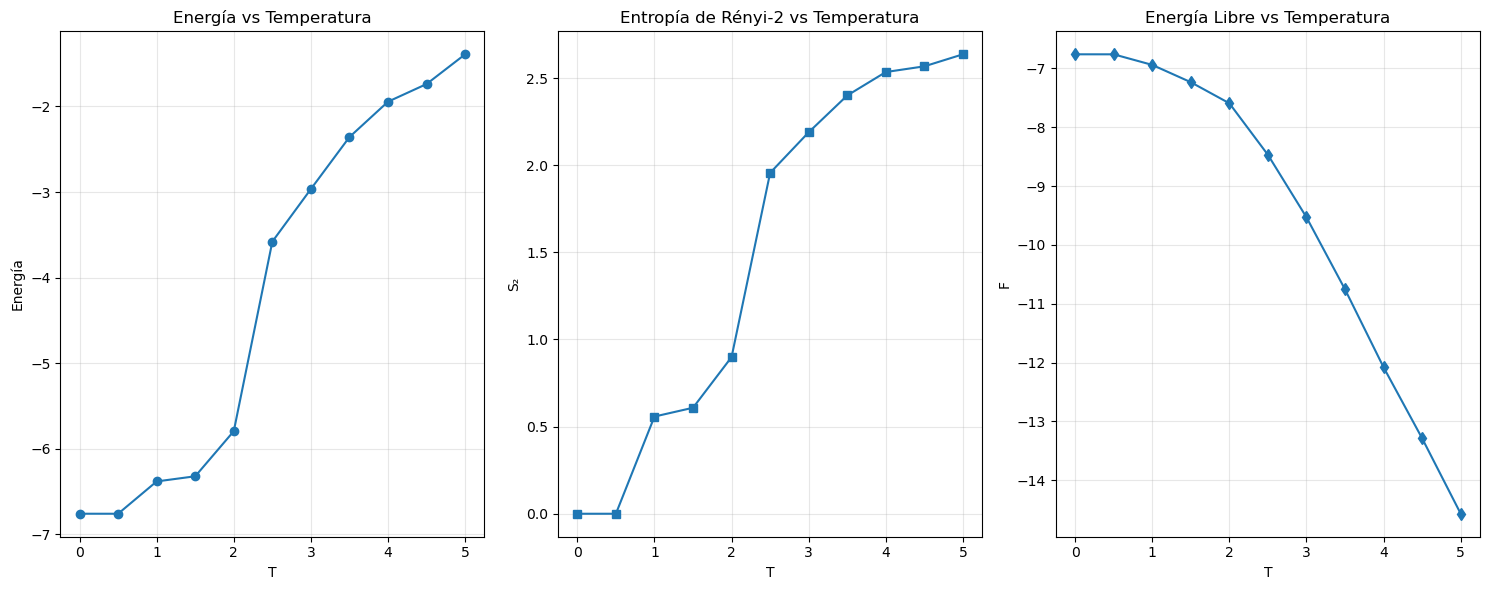

In [ ]:
sampler = nk.sampler.ARDirectSampler(hi_extended)
model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
vstate = nk.vqs.MCState(sampler, model, n_samples=40960, chunk_size=None)

T_array = np.linspace(0, 5, 11)
n_steps = 300

energy_results = []
entropy_results = []
free_energy_results = []
all_histories = []
best_params = None
os.makedirs(f"../data/N{N}/params", exist_ok=True)

for T_idx, T in enumerate(tqdm(T_array, desc="Temperaturas")):
    print(f"\n=== Temperatura T = {T:.3f} ===")

    vstate.init_parameters()
    if best_params is not None:
        vstate.parameters = best_params

    free_energy_history, best_F, best_energy, best_entropy = free_energy_minimize_SR_SGD(
        vstate=vstate,
        T=T,
        partition=partition,
        Hamiltonian=H_extended,
        n_steps=n_steps,
        verbose=True,
        plot=False,
        learning_rate = optax.linear_schedule(0.05, 0.001, n_steps),
        diag_shift=optax.linear_schedule(1e-1, 1e-4, n_steps),
        n_samples_sr=4096
    )
    best_params = vstate.parameters
    filename = f"../data/N{N}/params/params_T_{T:.3f}.msgpack"

    with open(filename, "wb") as f:
        f.write(serialization.to_bytes(best_params))

    energy_results.append(best_energy)
    entropy_results.append(best_entropy)
    free_energy_results.append(best_F)

    all_histories.append({
        "T": T,
        "free_energy": free_energy_history,
    })

    print(f"  Mejor resultado: E={best_energy:.4f}, S₂={best_entropy:.4f}, F={best_F:.4f}")

# Visualización
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.plot(T_array, energy_results, 'o-')
plt.xlabel('T'); plt.ylabel('Energía'); plt.title('Energía vs Temperatura'); plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(T_array, entropy_results, 's-')
plt.xlabel('T'); plt.ylabel('S₂'); plt.title('Entropía de Rényi-2 vs Temperatura'); plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(T_array, free_energy_results, 'd-')
plt.xlabel('T'); plt.ylabel('F'); plt.title('Energía Libre vs Temperatura'); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("output.png", dpi=200, bbox_inches="tight")
plt.show()

os.makedirs(f"../data/N{N}", exist_ok=True)

data = {
    "T": [float(T) for T in T_array],
    "energy": [float(x) for x in energy_results],
    "entropy": [float(x) for x in entropy_results],
    "free_energy": [float(x) for x in free_energy_results],
}

with open(f"../data/N{N}/results_N{N}_vs_T.txt", "w") as f:
    json.dump(data, f, indent=2)


Scipy minimization

In [ ]:
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model)
vstate.init_parameters

result = free_energy_minimize_scipy(
    vstate,
    T=0.9,
    partition=partition,
    Hamiltonian=H_extended,
    method="BFGS",
    options={"maxiter": 10000},
    verbose=False
)

print(result["result"].success)
print(f"Best F={result['best_F']:.6f}, E={result['best_energy']:.6f}, S₂={result['best_entropy']:.6f}")

In [ ]:
T_array_scipy = np.linspace(0, 10, 60)
model = RBM_Z2(alpha=1, trivial_Z2=True)

energy_results_scipy = []
entropy_results_scipy = []  
free_energy_results_scipy = []

for T in T_array_scipy:
    vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model) 
    result = free_energy_minimize_scipy(
        vstate,
        T=T,
        partition=partition,
        Hamiltonian=H_extended,
        method="L-BFGS-B",
        options={"maxiter": 50000},
        verbose=False
    )
    energy_results_scipy.append(result["best_energy"])
    entropy_results_scipy.append(result["best_entropy"])
    free_energy_results_scipy.append(result["best_F"])
    print(f"T={T:.3f} -- F={result['best_F']:.6f}, E={result['best_energy']:.6f}, S₂={result['best_entropy']:.6f}, {result['result'].success}")

plt.plot(T_array_scipy, free_energy_results_scipy, label=r"$F$")
plt.plot(T_array_scipy, energy_results_scipy, label=r"$\langle H\rangle$")
plt.plot(T_array_scipy, entropy_results_scipy, label=r"$S_2$")
plt.legend()
plt.show()

In [ ]:
#Comparar con scipy
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.scatter(T_array, free_energy_results, color="Blue", s=10, alpha=0.5, label="RBM")
ax1.plot(T_array_scipy, free_energy_results_scipy, color="Blue", label="Scipy")
ax1.set_xlabel("T")
ax1.set_ylabel("$F$")
ax1.set_title("Free energy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.scatter(T_array, energy_results, color="Orange", s=10, alpha=0.5, label="RBM")
ax2.plot(T_array_scipy, energy_results_scipy, color="Orange", label="Scipy")
ax2.set_xlabel("T")
ax2.set_ylabel("$<H>$")
ax2.set_title("$Energy$")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.scatter(T_array, entropy_results, color="Green", s=10, alpha=0.5, label="RBM")
ax3.plot(T_array_scipy, entropy_results_scipy, color="Green", label="Scipy")
ax3.set_xlabel("T")
ax3.set_ylabel("$S_2$")
ax3.set_title("Entanglement entropy")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()